# Exact Diagonalization

Exact diagonalization is a numerical method that involves directly solving for the eigenvalues and eigenvectors of the Hamiltonian. In this instance, we will use this method to understand the $k$ interaction by turning off the the $J$ and $h$ parameters:

$$ \mathcal{H_k} = \sum_i k_R(\sigma_i^x \sigma_{i+2}^y- \sigma_i^z\sigma_{i+1}^y\sigma_{i+2}^x)+k_L(\sigma_i^x\sigma_{i+1}^y\sigma_{i+2}^z - \sigma_{i}^y\sigma_{i+2}^x) $$

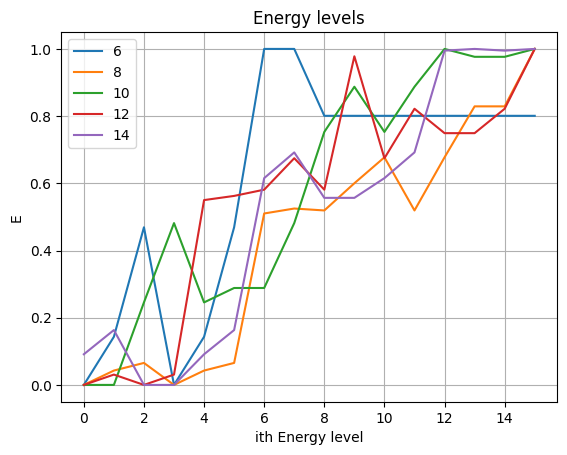

In [ ]:
from ed_utils import *

J = 0
h = 0
k_l = 1
k_r = k_l
eL = [6, 8, 10, 12, 14]

for L in eL:
    H = Ham(J, h, k_l, k_r, L)  # create the Hamiltonian
    N = 16  # number of energy levels
    E, psi = lg.eigsh(H, k=16, which='SA')
    psi0 = psi.T[0] # ground state
    E -= np.min(E)
    E /= np.abs(np.max(E) - np.min(E))
    
    # energy
    plt.plot(range(N), E, label=f"{L}")

    # magnetization profile
    # i = [i for i in range(L)]
    # mag = []
    # for site in i:
    #     mag.append(operator(site, X, psi0))
    
    # plt.plot([L for _ in range(L)], mag, label=f"{L}")

plt.title("Energy levels")
plt.xlabel("ith Energy level")
plt.ylabel("E")
plt.grid()
plt.legend()
plt.show()

# Reimplementation using QuSpin

In [1]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ed_utils import *

In [6]:
import numpy as np
import matplotlib.pyplot as plt

L = 10
var_num = 11

# perform ed
basis = spin_basis_1d(L, pauli=1)
scan_var = "h"
opp = "k" if scan_var == "h" else "h"
values = np.linspace(0, 2, var_num)
set = 0

exact_diagonalization_line(values=values, scan_var=scan_var, opp=opp, set=set, basis=basis, L=L)

1it [00:01,  1.93s/it]

(1024,)


2it [00:03,  1.68s/it]

(1024,)


3it [00:04,  1.50s/it]

...

(1024,)


10it [00:14,  1.47s/it]

(1024,)


11it [00:16,  1.50s/it]

(1024,)


In [ ]:
results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"

# --- entropy ---
single_site_entropy_curves = []
half_chain_entropy = []

# --- magnetization string ---
mx_list = np.zeros((var_num, L))
my_list = np.zeros((var_num, L))
mz_list = np.zeros((var_num, L))

# --- magnetization center ---
mz_mid_list=[]
my_mid_list=[]
mx_mid_list =[]

# --- correlation ---
xx_corr = np.zeros((var_num, L//2 - 1))
xy_corr = np.zeros((var_num, L//2 - 1))
xz_corr = np.zeros((var_num, L//2 - 1))
yy_corr = np.zeros((var_num, L//2 - 1))
yz_corr = np.zeros((var_num, L//2 - 1))
zz_corr = np.zeros((var_num, L//2 - 1))

for ind, i in enumerate(sorted(os.listdir(results))):
    psi = np.loadtxt(os.path.join(results,i), dtype=np.complex128)
    
    #--- Entanglement---
    single_site_entropy_curves.append(entanglement_string(psi, basis))
    half_chain_entropy.append(entanglement_site(psi, basis))

    # --- string measurements ---
    mx_list[ind] = magnetization_string('x', psi, basis)
    my_list[ind] = magnetization_string('y', psi, basis)
    mz_list[ind] = magnetization_string('z', psi, basis)

    # --- mid-chain measurements ---
    mz_mid_list.append(magnetization_site('z', L//2, psi, basis))
    my_mid_list.append(magnetization_site('y', L//2, psi, basis))
    mx_mid_list.append(magnetization_site('x', L//2, psi, basis))

    # --- correlators ---
    xx_corr[ind] = correlator_string('x', 'x', L//2, psi, basis)
    xy_corr[ind] = correlator_string('x', 'y', L//2, psi, basis)
    xz_corr[ind] = correlator_string('x', 'z', L//2, psi, basis)
    yy_corr[ind] = correlator_string('y', 'y', L//2, psi, basis)
    yz_corr[ind] = correlator_string('y', 'z', L//2, psi, basis)
    zz_corr[ind] = correlator_string('z', 'z', L//2, psi, basis)

/home/silvanita/Desktop/thesis/master_thesis/books/ed_utils.py:190: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


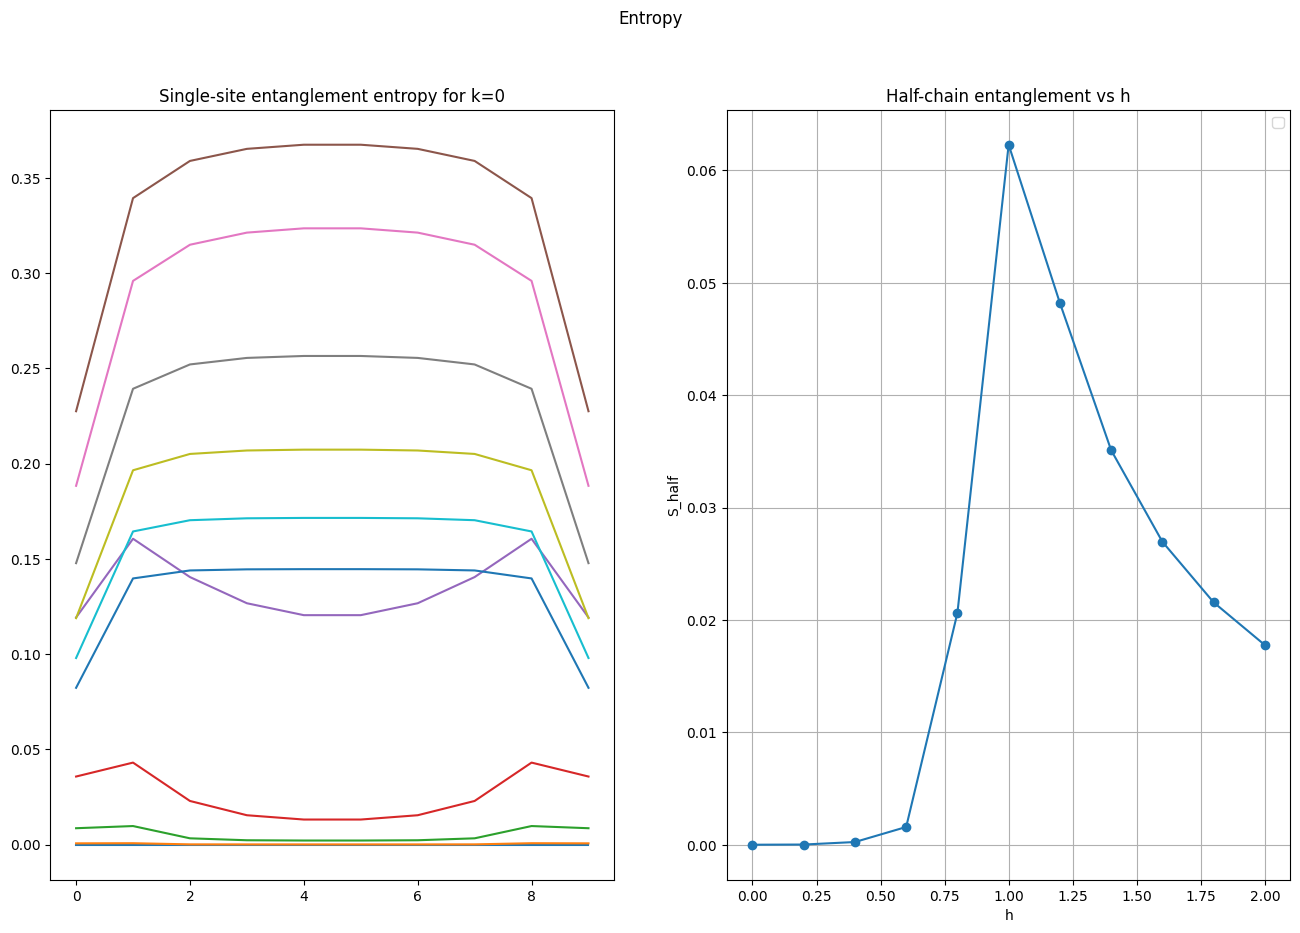

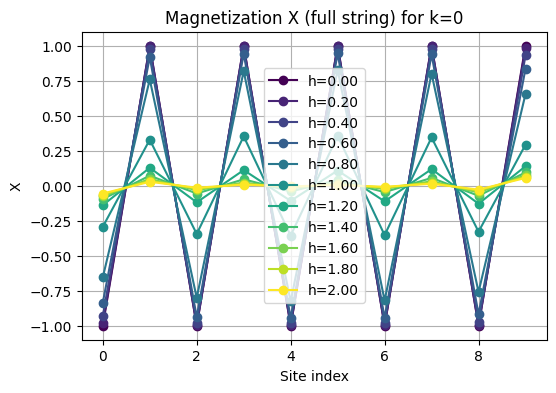

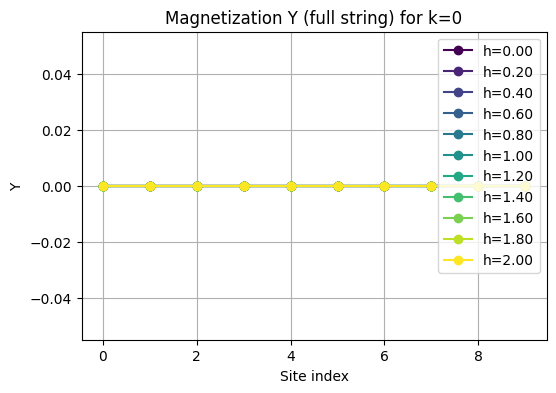

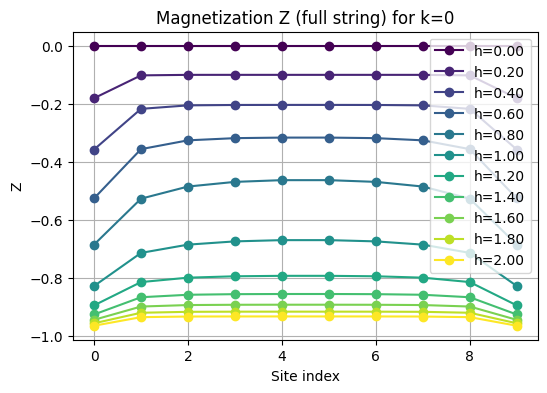

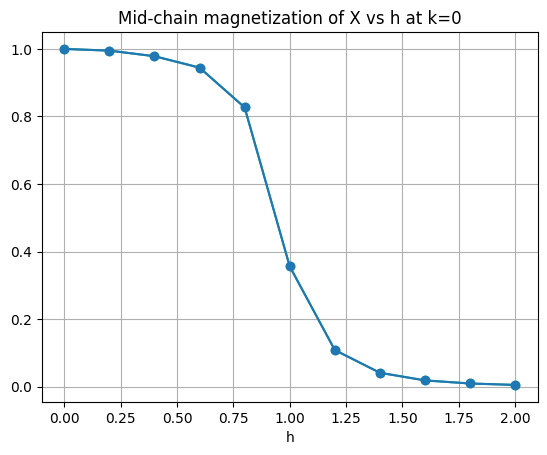

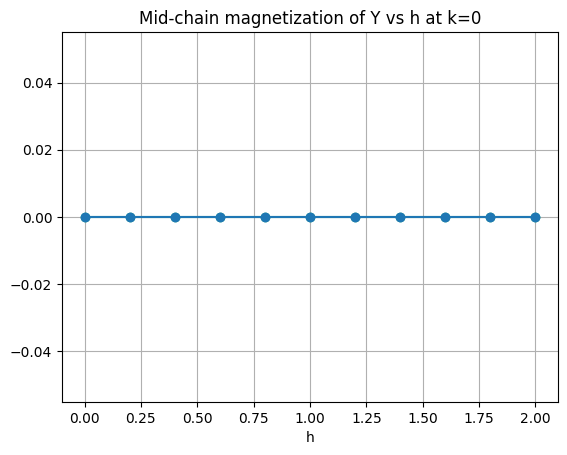

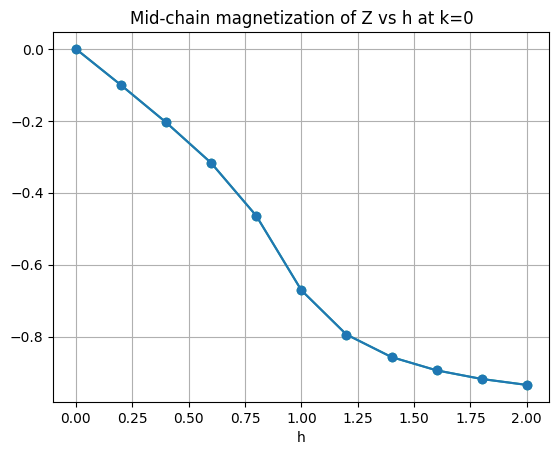

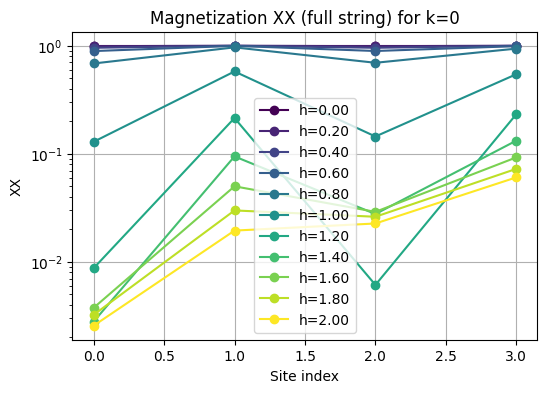

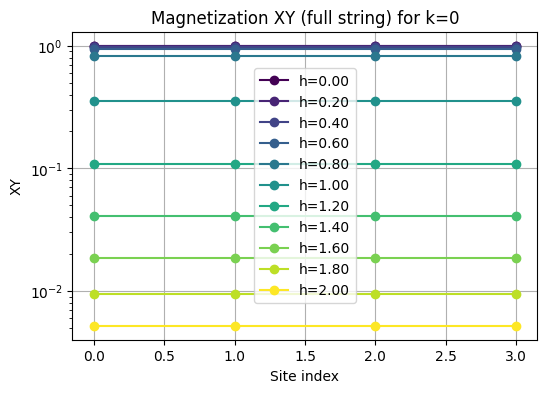

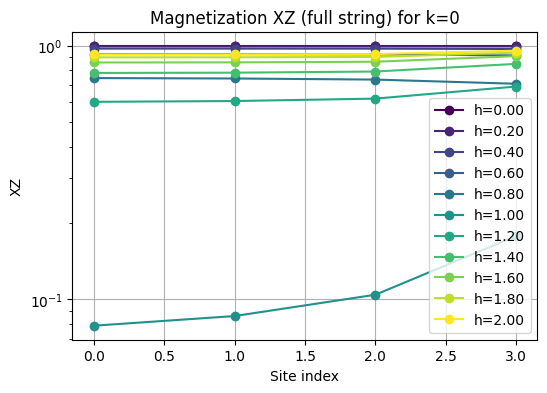

/home/silvanita/Desktop/thesis/master_thesis/ed_venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


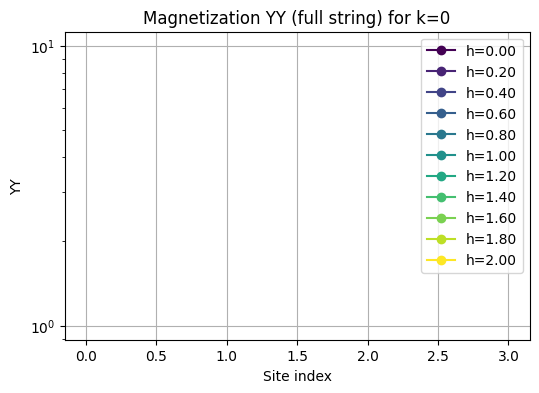

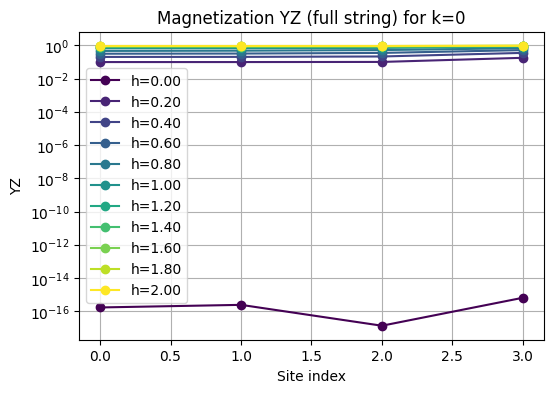

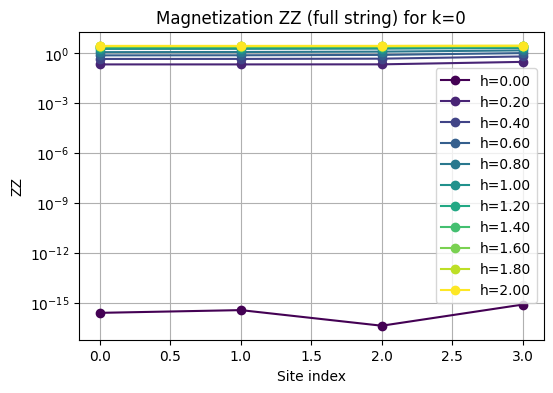

In [ ]:
# --- entropy ---
plot_entropy(single_site_entropy_curves, half_chain_entropy, values=values, scan_var=scan_var, opp=opp, set=set)

# --- string magnetization ----
plot_string('X', values, mx_list, scan_var=scan_var, opp=opp, set=set)
plot_string('Y', values, my_list, scan_var=scan_var, opp=opp, set=set)
plot_string('Z', values, mz_list, scan_var=scan_var, opp=opp, set=set)

# --- site magnetization ---
plot_site('X', values, mx_mid_list, scan_var=scan_var, opp=opp, set=set)
plot_site('Y', values, my_mid_list, scan_var=scan_var, opp=opp, set=set)
plot_site('Z', values, mz_mid_list, scan_var=scan_var, opp=opp, set=set)

# --- correlations ---
plot_correlator('XX', values, xx_corr, scan_var=scan_var, opp=opp, set=set)
plot_correlator('XY', values, xy_corr, scan_var=scan_var, opp=opp, set=set)
plot_correlator('XZ', values, xz_corr, scan_var=scan_var, opp=opp, set=set)
plot_correlator('YY', values, yy_corr, scan_var=scan_var, opp=opp, set=set)
plot_correlator('YZ', values, yz_corr, scan_var=scan_var, opp=opp, set=set)
plot_correlator('ZZ', values, zz_corr, scan_var=scan_var, opp=opp, set=set)

In [ ]:
# --- Energy calculations ---